In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Currently using {DEVICE}")

Currently using cuda


In [2]:
from src.data_import import load_fashion_mnist, load_mnist_digit, load_CIFAR10

train_loader, test_loader = load_CIFAR10(32, shuffle=True, class_subset=[5])

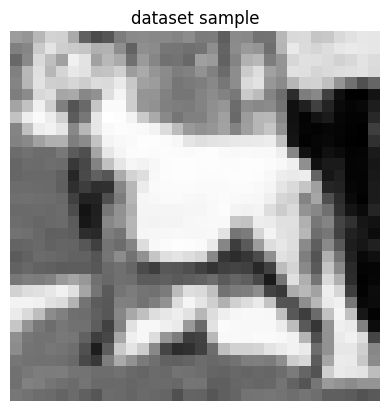

label: 5
torch.Size([32, 1, 32, 32])


In [3]:
from src.plot import show_single_sample, show_grid

x_real, _ = next(iter(train_loader))
show_single_sample(x_real[0], "dataset sample", cmap="Grays")
#print label
print("label:", _[0].item())
print(x_real.shape)

In [4]:
from src.model import EnergyHead, EBM, SmallEBM

n_heads = 6

model = SmallEBM(in_dim=(1,32,32), mid_dim=150, n_heads=n_heads, batch_size=32)

model.to(DEVICE)

SmallEBM(
  (heads): ModuleList(
    (0-5): 6 x SmallEnergyHead(
      (net): Sequential(
        (0): Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1))
        (1): Flatten(start_dim=1, end_dim=-1)
        (2): GELU(approximate='none')
        (3): Linear(in_features=900, out_features=1, bias=True)
      )
    )
  )
)

In [5]:
from src.sampler import ReplaySampler
from src.information import TotalCorrelationEstimator

sampler = ReplaySampler(model, img_shape=(1, 32, 32), buffer_size=600, noise_fraction=0.05, device=DEVICE)
total_correlation_estimator = TotalCorrelationEstimator(n_heads, hidden_dim=64)
total_correlation_estimator.to(DEVICE)

In [ ]:
from src.train import train_one_epoch_TC
#torch.autograd.set_detect_anomaly(True, check_nan=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.0, 0.999))

for epoch in range(10):
    epoch_loss = train_one_epoch_TC(

        model, 
        total_correlation_estimator, 
        sampler, 
        train_loader, 
        optimizer,

        sample_steps=30,
        sample_step_size=1.0,
        sample_noise_std=0.005,
        energy_reg=0.5,
        tc_reg=1e-2,

        device=DEVICE
    )
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

100%|██████████| 157/157 [00:46<00:00,  3.41it/s]


  CD:     5.7039
  Reg:    16.2446
  TC:     0.1214
  E_real: 0.5418
  E_fake: -5.1621
  Gap:    5.7039
Epoch 1, Loss: 22.0700


100%|██████████| 157/157 [00:38<00:00,  4.12it/s]


  CD:     1.7528
  Reg:    1.7182
  TC:     0.3110
  E_real: 0.1017
  E_fake: -1.6511
  Gap:    1.7528
Epoch 2, Loss: 3.7820


100%|██████████| 157/157 [00:37<00:00,  4.14it/s]


...

100%|██████████| 157/157 [00:25<00:00,  6.16it/s]


  CD:     0.2447
  Reg:    0.1925
  TC:     0.9495
  E_real: 0.0362
  E_fake: -0.2086
  Gap:    0.2447
Epoch 4, Loss: 1.3868


100%|██████████| 157/157 [00:31<00:00,  4.93it/s]


  CD:     0.1064
  Reg:    0.1438
  TC:     1.4509
  E_real: 0.0492
  E_fake: -0.0573
  Gap:    0.1064
Epoch 5, Loss: 1.7012


  8%|▊         | 12/157 [00:01<00:18,  7.72it/s]

In [ ]:
from src.diagnostic import diagnose

diagnose(model, sampler, (1, 32, 32), train_loader, test_loader, device=DEVICE, n_samples=16)

EBM DIAGNOSTICS

[1] Energy on real data
  Train  →  mean=-0.0517,  std=0.1051
  Test   →  mean=-0.0606,  std=0.1019
  |E_test - E_train| = 0.0089  (ok)

[2] Energy on fake data (Langevin samples)
  Fake   →  mean=-0.5373,  std=0.0617
  Gap (E_real_train - E_fake) = 0.4856  (WARNING: gap inverted)

[3] Energy on pure noise


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x676 and 900x1)

In [ ]:
samples = sampler.generate(10, steps=200, step_size=10, noise_std=0.005)

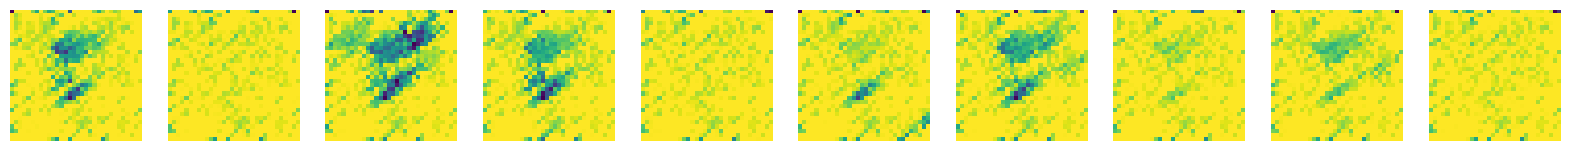

In [ ]:
show_grid(samples, 10)

In [ ]:
from src.plot import visualize_heads

fig = visualize_heads(model, sampler.buffer, (1,32,32), DEVICE, k=3, cmap="Grays")

TypeError: visualize_heads() got multiple values for argument 'k'

In [ ]:
def visualize_head_gradients(model, x, device, idx=0):
    """
    Per una singola immagine, mostra dE_i/dx per ogni testa.
    Rivela cosa "guarda" ogni testa nell'immagine.
    """
    model.eval()
    img = x[idx].unsqueeze(0).to(device)  # (1, 1, 28, 28)

    n_heads = len(model.heads)
    fig, axes = plt.subplots(1, n_heads + 1, figsize=(3 * (n_heads + 1), 3))

    # Immagine originale
    axes[0].imshow(img.squeeze().cpu().numpy(), cmap="gray")
    axes[0].set_title("Input")
    axes[0].axis("off")

    for i, head in enumerate(model.heads):
        x_ = img.detach().requires_grad_(True)
        with torch.enable_grad():
            e = head(x_).sum()
            g = torch.autograd.grad(e, x_, only_inputs=True)[0]

        g_np = g.squeeze().cpu().detach().numpy()
        g_np = np.abs(g_np)
        g_np = (g_np - g_np.min()) / (g_np.max() - g_np.min() + 1e-8)

        axes[i + 1].imshow(g_np, cmap="hot")
        axes[i + 1].set_title(f"Head {i}\n|dE/dx|")
        axes[i + 1].axis("off")

    plt.suptitle("Gradient maps per testa", fontsize=12)
    plt.tight_layout()
    plt.show()